## 2. Testes de convergência de séries

Neste notebook vamos explorar, por meio de **experimentos computacionais**, alguns critérios usados para decidir se uma série converge ou diverge: o teste da comparação, o teste da integral, o teste da razão e o teste da raiz. O objetivo aqui não é a demonstração formal de cada teste, mas desenvolver intuição observando o comportamento numérico das séries. Ao final, veremos como o `SymPy` pode auxiliar nesse tipo de análise.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (4, 3)

### 2.1 Teste da comparação

*Ideia:* se $0 \le a_n \le b_n$ para todo $n$ suficientemente grande e $\sum b_n$ converge, então $\sum a_n$ também converge. Se $\sum a_n$ diverge, então $\sum b_n$ também diverge.

**Exemplo 2.1:** vamos comparar $a_n = \dfrac{1}{n^2+n}$ com a p-série conhecida $b_n = \dfrac{1}{n^2}$.

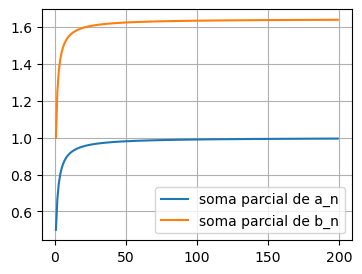

soma parcial de a_n (n=200): 0.9949999999999993
soma parcial de b_n (n=200): 1.6399215460149972


In [2]:
n = np.arange(1, 200)
a = 1/(n**2+n)
b = 1/(n**2)

plt.plot(n, np.cumsum(a), label='soma parcial de a_n')
plt.plot(n, np.cumsum(b), label='soma parcial de b_n')
plt.legend(); plt.grid(); plt.show()

print('soma parcial de a_n (n=200):', np.cumsum(a)[-1])
print('soma parcial de b_n (n=200):', np.cumsum(b)[-1])

**Exemplo 2.2:** Consideremos as séries$\sum_{n=1}^{\infty} \frac{1}{2^n+1}$ e $\sum_{n=1}^{\infty} \frac{1}{2^n}$.

Sabendo que a segunda série converge para 1 e usando o **teste da comparação**, temos que para todo $n\geq 1$

$$
0 < \frac{1}{2^n+1} < \frac{1}{2^n}.
$$

então, segue, pelo teste da comparação, que a série

$$
\sum_{n=1}^{\infty} \frac{1}{2^n+1}
$$

também é convergente. Temos que
$$
\sum_{n=1}^{\infty} \frac{1}{2^n+1}
<
\sum_{n=1}^{\infty} \frac{1}{2^n}
=1.
$$

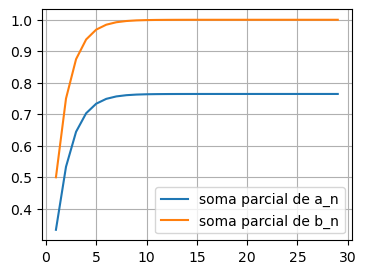

soma parcial de a_n (n=200): 0.764499778485799
soma parcial de b_n (n=200): 0.9999999981373549


In [3]:
n = np.arange(1, 30)
a = 1/(2**n+1)
b = 1/(2**n)

plt.plot(n, np.cumsum(a), label='soma parcial de a_n')
plt.plot(n, np.cumsum(b), label='soma parcial de b_n')
plt.legend(); plt.grid(); plt.show()

print('soma parcial de a_n (n=200):', np.cumsum(a)[-1])
print('soma parcial de b_n (n=200):', np.cumsum(b)[-1])

**Observação:** No teste da comparação, a desigualdade entre os termos das séries não precisa ser satisfeita para todo $n\geq1$. É suficiente que ela seja válida para todo $n\geq n_0$, para algum $n_0$ suficientemente grande. Os primeiros termos, em quantidade finita, não alteram a convergência ou divergência da série.

**Exemplo 2.3:** Considere a série $\sum_{n=1}^{\infty} \frac{n+10}{n^3}.$ Queremos investigar sua convergência utilizando o teste da comparação. Para isso, podemos compará-la com a série $\sum_{n=1}^{\infty} \frac{1}{n^2}$,que é uma série $p$ convergente, pois $p=2>1$.

Observe que a desigualdade

$$\frac{n+10}{n^3}\leq\frac{1}{n^2}$$ 

não é válida para todos os valores de $n$. Entretanto, isso não impede a aplicação do teste da comparação. Para $n\geq10$, temos $$
n+10\leq2n,
$$

e, consequentemente,

$$0<\frac{n+10}{n^3}\leq\frac{2n}{n^3}.$$

Como a série $\sum_{n=10}^{\infty}\frac{2}{n^2}$ é convergente, segue, pelo teste da comparação, que $\sum_{n=10}^{\infty}\frac{n+10}{n^3}$ também é convergente.

Graficamente,plotando os termos de 7 a 30, temos:

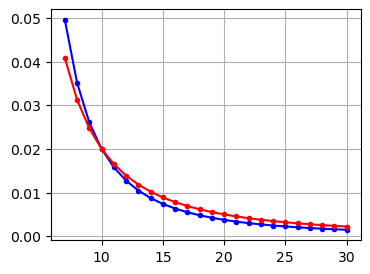

In [4]:
n = np.arange(7, 31)

a_n = (n + 10) / n**3
b_n = 2 / n**2

# Gráfico
plt.figure()

plt.plot(n, a_n, 'b.-')
plt.plot(n, b_n, 'r.-')
plt.grid(); plt.show()
plt.show()

**Atividade 2.1: (Teste da comparação)** Para cada uma das séries abaixo, investigue sua convergência comparando o comportamento da série graficamente ou numericamente. Confirme pelo teste da comparação.

**(a)** (Série convergente) Analise a série $ \displaystyle \sum_{n=1}^{\infty} \frac{1}{n^2+3n+1}$.

Compare-a com uma série $p$ adequada e determine sua convergência.

**(b)** (Série divergente) Analise a série $ \displaystyle \sum_{n=1}^{\infty} \frac{n+1}{n^2+1}$.

Compare-a com uma série harmônica adequada e determine sua convergência ou divergência.

**(c)** (Comparação inconclusiva) Considere a série $\displaystyle \sum_{n=1}^{\infty} \frac{1}{n}$. Compare-a com a série $\displaystyle \sum_{n=1}^{\infty} \frac{1}{n^2}$.

Verifique se a desigualdade entre os termos permite concluir, pelo teste da comparação, se a série harmônica converge ou diverge.

**(d)** (Comparação válida somente para $n$ grande) Considere a série $\displaystyle \sum_{n=1}^{\infty} \frac{n+10}{n^3}$. Compare-a com a série $\displaystyle \sum_{n=1}^{\infty}\frac{2}{n^2}$.

Observe que a desigualdade necessária para a comparação não é válida para todos os valores de $n$. Determine um índice $n_0$ a partir do qual a comparação é válida e conclua sobre a convergência da série.

### 2.2 Teste da integral

*Ideia:* se $f$ é uma função positiva, contínua e decrescente para $x\ge N$ e $a_n=f(n)$, então $\sum a_n$ converge se, e somente se, $\int_N^\infty f(x)\,dx$ converge.


**Exemplo 2.4:** (Teste da integral) Considere a série $\sum_{n=1}^{\infty}\frac{1}{n^2} = 1+\frac{1}{2^2}+\frac{1}{3^2}+\frac{1}{4^2}+\cdots$. Queremos investigar se essa série é convergente. Uma forma de fazer isso é comparar seus termos com a função $f(x)=\frac{1}{x^2}$.

A função $f(x)$ é **positiva, contínua e decrescente** para $x\geq1$. Podemos, portanto, utilizar o **teste da integral**, que estabelece que a série $\sum_{n=1}^{\infty}f(n)$ e a integral imprópria $\int_1^\infty f(x)\,dx$ possuem o mesmo comportamento quanto à convergência.

Calculando a integral

$$
\int_1^\infty\frac{1}{x^2}\,dx
= \lim_{b\to\infty}\left[-\frac{1}{x}\right]_1^b=
\lim_{b\to\infty}
\left(1-\frac{1}{b}\right)
=1.
$$

Como a integral é convergente, concluímos, pelo **teste da integral**, que
$\sum_{n=1}^{\infty}\frac{1}{n^2} \text{ é convergente}$.

Além disso, podemos visualizar geometricamente essa comparação. Como $f(x)=1/x^2$ é decrescente, os retângulos de base $1$ e altura $f(n)$ ficam abaixo da curva em determinados intervalos. A soma das áreas desses retângulos corresponde aos termos da série:

$$
\frac{1}{1^2}+\frac{1}{2^2}+\frac{1}{3^2}+\cdots.
$$

O gráfico a seguir permite visualizar essa relação entre a série e a integral.

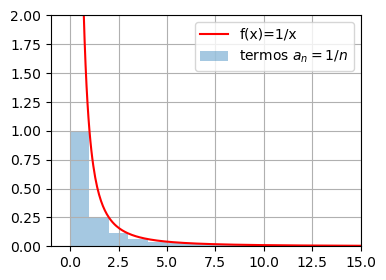

In [5]:
n = np.arange(1, 15)
plt.bar(n-1, 1/n**2, width=1.0, align='edge', alpha=0.4, label='termos $a_n=1/n$')

x = np.linspace(0.1, 15, 300)
plt.plot(x, 1/x**2, 'r', label='f(x)=1/x')

plt.legend()
plt.ylim(0,2)
plt.xlim(-1,15)
plt.grid()
plt.show()

O gráfico mostra a curva $y=1 / x^2$ e retângulos colocados abaixo dela. A base de cada retângulo é um intervalo de comprimento 1, a altura é igual ao valor da função $y=1 / x^2$ na extremidade direita do intervalo.

Dessa forma, a soma das áreas dos retângulos é

$$
\frac{1}{1^2}+\frac{1}{2^2}+\frac{1}{3^2}+\frac{1}{4^2}+\frac{1}{5^2}+\cdots=\sum_{n=1}^{\infty} \frac{1}{n^2}
$$

Se excluirmos o primeiro retângulo, a área total dos retângulos remanescentes será menor que a área sob a curva $y=1 / x^2$ para $x \geq 1$, que é o valor da integral $\int_1^{\infty}\left(1 / x^2\right) d x.$


**Exemplo 2.5:** Vamos comparar visualmente a série harmônica $a_n=1/n$ com a integral $\int_1^\infty \frac{1}{x}\,dx$. 

Usamos SymPy para calcular a integral:

In [6]:
x = sp.symbols('x', positive=True)
integral = sp.integrate(1/x, (x, 1, sp.oo))
display(integral)

oo

Graficamente, temos:

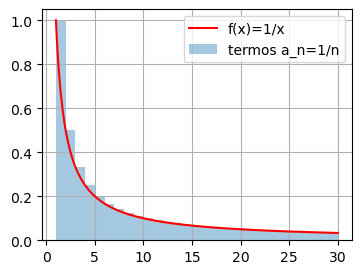

In [7]:
n = np.arange(1, 30)
plt.bar(n, 1/n, width=1.0, align='edge', alpha=0.4, label='termos a_n=1/n')

x = np.linspace(1, 30, 300)
plt.plot(x, 1/x, 'r', label='f(x)=1/x')

plt.legend()
plt.grid()
plt.show()

**Atividade 2.2: (Teste da integral)** Para cada uma das séries abaixo, investigue sua convergência comparando o comportamento da série graficamente ou numericamente. Confirme pelo teste da integral usando SymPy para calcular a integral imprópria.

(a) $\sum_{n=2}^{\infty} =\dfrac{1}{n\ln(n)^2}$ 

(b) $\sum_{n=1}^{\infty} n^2 e^{-n^3}$

(c) $\sum_{n=1}^{\infty} \dfrac{\operatorname{tg}^{-1} n}{1+n^2}$

(d) $\sum_{n=1}^{\infty} \dfrac{\ln n}{n}$

Use o Teste da Integral para determinar se a série é convergente ou divergente.

### 2.3 Teste da razão

*Ideia:* calculamos $L=\lim\limits_{n\to\infty}\left|\dfrac{a_{n+1}}{a_n}\right|$. Se $L<1$ a série $\displaystyle \sum_{n=1}^{\infty} a_n$ converge (absolutamente); se $L>1$ a série diverge; se $L=1$ o teste é inconclusivo.

**Exemplo 2.6:** Vamos primeiro investigar numericamente $a_n = \dfrac{2^n}{n!}$. E depois aplicar o teste da razão calculando o limite com SymPy.

In [8]:
n = sp.symbols('n', positive=True, integer=True)
a = 2**n/sp.factorial(n)

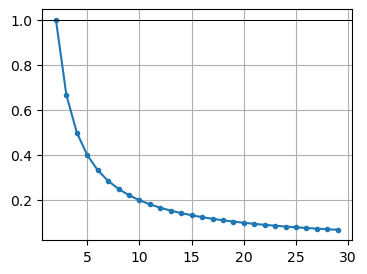

razao a_(n+1)/a_n para os ultimos termos: [0.08 0.07692307692307691 0.07407407407407408 0.07142857142857142
 0.06896551724137932]


In [9]:
import math
n = np.arange(1, 30)
a = 2.0**n/np.array([math.factorial(int(k)) for k in n])
razao = a[1:]/a[:-1]

plt.plot(n[1:], razao, '.-')
plt.axhline(1, color='k', lw=0.7)
plt.grid(); plt.show()
print('razao a_(n+1)/a_n para os ultimos termos:', razao[-5:])

Também podemos calcular o limite simbolicamente com `sympy`:

In [10]:
n = sp.symbols('n', positive=True, integer=True)
a = 2**n/sp.factorial(n)
display(a)

2**n/factorial(n)

In [11]:
L = sp.limit(abs(a.subs(n, n+1)/a), n, sp.oo)
display(L)

0

Como $L=0$, a série é convergente.

Para saber o valor (aproximado) para o qual a série converge, podemos calcular a soma dos 1000 primeiros termos:

In [12]:
soma = 0
for n in range(1,1000):
    soma+=2**n/math.factorial(n)
print(soma)

6.389056098930649


Mas também podemos obter uma solução exata calculando analiticamente com SymPy.

In [13]:
n = sp.symbols('n', positive=True, integer=True)
soma = sp.summation(a, (n, 1, sp.oo))
soma

-1 + exp(2)

ou

In [14]:
soma.evalf()

6.38905609893065

**Exemplo 2.7:** [(Fonte)](https://integrada.minhabiblioteca.com.br/reader/books/9786555584103/pageid/193) Dada a série $\sum_{n=1}^{\infty}(-1)^n \frac{n^3}{3^n}$, pelo teste da razão, temos:


$$
\begin{aligned}
\left|\frac{a_{n+1}}{a_n}\right| & =\left|\frac{\frac{(-1)^{n+1}(n+1)^3}{3^{n+1}}}{\frac{(-1)^n n^3}{3^n}}\right|=\frac{(n+1)^3}{3^{n+1}} \cdot \frac{3^n}{n^3} \\
& =\frac{1}{3}\left(\frac{n+1}{n}\right)^3=\frac{1}{3}\left(1+\frac{1}{n}\right)^3 \rightarrow \frac{1}{3}<1
\end{aligned}
$$

Portanto converge. Com SymPy fazemos:

In [15]:
n = sp.symbols('n', positive=True, integer=True)
a = (-1)**n * (n**3/3**n)
display(a)

(-1)**n*n**3/3**n

In [16]:
# resultado do limite
L = sp.limit(abs(a.subs(n, n+1)/a), n, sp.oo)
display(L)

1/3

In [17]:
# resultado da soma
sp.summation(a, (n, 1, sp.oo))

3/128

**Atividade 2.3: (Teste da Razão)** Para cada uma das séries abaixo, investigue sua convergência testando numérica e graficamente. Em caso convergente obtenha o valor limite. Confirme a convergência pelo teste da Razão.

**(a)** $\sum_{n=1}^{\infty} \frac{10^n}{(n+1) 4^{2 n+1}}$

**(b)** $\sum_{n=0}^{\infty} \frac{(-3)^n}{(2 n+1)!}$

**(c)** $\sum_{n=1}^{\infty} \frac{(2 n)!}{(n!)^2}$





### 2.4 Teste da raiz

*Ideia:* calculamos $L=\lim\limits_{n\to\infty}\sqrt[n]{|a_n|}$. Os critérios de convergência/divergência são os mesmos do teste da razão.

**Exemplo 2.8:** Vamos investigar numericamente $a_n = \left(\dfrac{n}{n+1}\right)^{n^2}$.

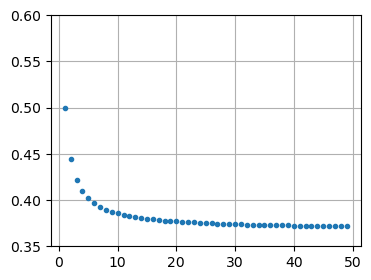

raiz n-esima para os ultimos termos: [0.37192956 0.3718423  0.37175872 0.3716786  0.37160171]


In [18]:
n = np.arange(1, 50)
a = (n/(n+1))**(n**2.0)
raiz = a**(1/n)

plt.plot(n, raiz, '.')
plt.ylim(0.35,0.6)
plt.grid()
plt.show()
print('raiz n-esima para os ultimos termos:', raiz[-5:])

Também podemos calcular $L$ simbolicamente com `sympy`, elevando o termo geral à potência $1/n$ (a raiz $n$-ésima):

In [19]:
n = sp.symbols('n', positive=True, integer=True)
a = (n/(n+1))**(n**2)
raiz_n = sp.powsimp(a**(sp.Rational(1,1)/n), force=True)
display(raiz_n)
L = sp.limit(raiz_n, n, sp.oo)
display(L)

(n/(n + 1))**n

exp(-1)

Como $L=e^{-1}<1$, a série converge — resultado consistente com a curva se aproximando de $e^{-1}\approx0{,}368$ no gráfico acima.

**Exemplo 2.9:** Vamos agora resolver um exemplo de forma totalmente simbólica, para $b_n=\left(\dfrac{3n+2}{4n+1}\right)^{2n}$. Pelo teste da raiz,

$$
\sqrt[n]{|b_n|} = \left(\frac{3n+2}{4n+1}\right)^{2} \xrightarrow[n\to\infty]{} \left(\frac34\right)^2=\frac{9}{16}<1,
$$

logo a série converge. Confirmando com SymPy:

In [20]:
n = sp.symbols('n', positive=True, integer=True)
b = ((3*n+2)/(4*n+1))**(2*n)
raiz_n = sp.powsimp(b**(sp.Rational(1,1)/n), force=True)
display(raiz_n)
L = sp.limit(raiz_n, n, sp.oo)
display(L)

(3*n + 2)**2/(4*n + 1)**2

9/16

**Atividade 2.4:** Use o teste da raiz para investigar a convergência de cada série abaixo, numérica e simbolicamente.

**(a)** $a_n = \left(\dfrac{2n+1}{3n}\right)^n$

**(b)** $a_n = \left(\dfrac{4n}{2n+1}\right)^n$

**(c)** $a_n = n\left(\dfrac{n}{n+2}\right)^{n^2}$

No item **(c)**, observe que o fator polinomial $n$ que multiplica a potência não altera o valor do limite $L$, pois $\sqrt[n]{n}\to1$ quando $n\to\infty$.

### 2.5 Usando SymPy para tratar séries

O `sympy` permite somar séries simbolicamente com `sp.Sum(...).doit()`, decompor termos gerais em frações parciais com `sp.apart`, e calcular limites com `sp.limit`, ferramentas úteis para confirmar (ou refutar) as conclusões dos experimentos numéricos acima.

**Exemplo 2.10:** Consideremos novamente a série $\displaystyle\sum_{n=1}^{\infty} \frac{1}{n(n+1)}$, já estudada acima. Com `sp.apart`, decompomos o termo geral em frações parciais, o que evidencia a telescopagem $\dfrac{1}{n(n+1)}=\dfrac1n-\dfrac1{n+1}$:

In [21]:
n = sp.symbols('n')
termo = 1/(n*(n+1))
display(sp.apart(termo))

-1/(n + 1) + 1/n

Em seguida, confirmamos com `sp.Sum(...).doit()` que a soma da série é exatamente $1$, como a telescopagem sugere:

In [22]:
n = sp.symbols('n', positive=True, integer=True)
soma = sp.Sum(1/(n*(n+1)), (n, 1, sp.oo))
display(soma, soma.doit())

Sum(1/(n*(n + 1)), (n, 1, oo))

1

**Exemplo 2.11:** Vamos confirmar simbolicamente a conclusão do Exemplo 2.1 (teste da comparação). Lá, comparamos $a_n=\dfrac{1}{n^2+n}$ com a p-série $b_n=\dfrac1{n^2}$, e a soma parcial numérica de $a_n$ em $n=200$ já se aproximava de $1$. Como $\dfrac{1}{n^2+n}=\dfrac{1}{n(n+1)}$, podemos obter a soma exata com `sp.Sum`:

In [23]:
n = sp.symbols('n', positive=True, integer=True)
a = 1/(n**2+n)
soma = sp.Sum(a, (n, 1, sp.oo))
display(soma, soma.doit())

Sum(1/(n**2 + n), (n, 1, oo))

1

**Atividade 2.5:** Retome séries investigadas nas atividades anteriores deste notebook e confirme suas conclusões usando as ferramentas simbólicas do `sympy`.

**(a)** Escolha uma série da Atividade 2.1 (teste da comparação) cujo termo geral admita decomposição em frações parciais. Use `sp.apart` para decompor o termo geral e `sp.Sum(...).doit()` para obter a soma exata (quando existir), comparando com a soma parcial numérica já obtida.

**(b)** Escolha uma série da Atividade 2.3 (teste da razão) ou da Atividade 2.4 (teste da raiz). Use `sp.limit` para recalcular simbolicamente o limite $L$ e confirme a conclusão sobre convergência ou divergência obtida anteriormente.

**Referências**

STEWART, James; CLEGG, Daniel; WATSON, Saleem. Cálculo v.2. 6. ed. Porto Alegre: +A Educação - Cengage Learning Brasil, 2022. E-book. p.668. ISBN 9786555584103. 